# Trabajo Final: Predicción del salario anual (CRISP-DM)
**Integrantes:** Daniel Jaramillo Guillén y Miguel Ángel López Ríos

## 3. Preparación de datos

Dataset: `Employee_Salaries.csv` (1.000 registros, 19 columnas). Objetivo: predecir `Salary` (salario anual en dólares), un problema de **regresión supervisada**.

Este cuaderno desarrolla los pasos 3.1 a 3.8 y exporta el dataset preparado para la fase de modelamiento (punto 4).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='deep')
os.makedirs('figuras', exist_ok=True)
SEED = 42

### Carga de datos
En Google Colab, si el archivo no está en el entorno, se abre un cuadro para subirlo.

In [2]:
ARCHIVO = 'Employee_Salaries.csv'
if not os.path.exists(ARCHIVO):
    from google.colab import files
    files.upload()

df_raw = pd.read_csv(ARCHIVO)
print(df_raw.shape)
df_raw.head()

(1000, 19)


,RecordID,Age,BirthYear,Gender,Education,JobTitle,YearsExperience,Department,JobLevel,CompanySize,Location,Remote,MonthlySalary,Salary,FullName,Phone,ZodiacSign,FavoriteColor,Hobby
0,REC00001,22.00,"2,004.00",Female,Bachelor,Director,0.00,IT,5,Large,City_023,Yes,"6,525.73","78,308.71",Person_1,"3,524,152,531.00",Sagittarius,Red,Photography
1,REC00002,34.40,"1,992.00",Male,Bachelor,Engineer,12.40,Sales,4,Large,City_011,Yes,"7,736.27","92,835.25",Person_2,"3,436,668,970.00",Pisces,Black,Cooking
2,REC00003,30.70,"1,995.00",Male,NaN,Specialist,6.70,IT,2,Large,City_002,No,"6,301.63","75,619.52",Person_3,"3,029,156,317.00",Libra,White,Sports
3,REC00004,65.00,"1,961.00",Male,High School,Analyst,40.00,Marketing,3,Medium,City_006,No,"9,925.44","119,105.30",Person_4,"3,836,615,886.00",Aquarius,Pink,Music
4,REC00005,24.60,"2,001.00",Female,PhD,Analyst,0.00,Operations,4,Small,City_010,No,"7,151.09","85,813.05",Person_5,"3,608,419,891.00",Virgo,Blue,Reading


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RecordID         1000 non-null   str    
 1   Age              904 non-null    float64
 2   BirthYear        1000 non-null   float64
 3   Gender           1000 non-null   str    
 4   Education        895 non-null    str    
 5   JobTitle         1000 non-null   str    
 6   YearsExperience  899 non-null    float64
 7   Department       891 non-null    str    
 8   JobLevel         1000 non-null   int64  
 9   CompanySize      1000 non-null   str    
 10  Location         1000 non-null   str    
 11  Remote           1000 non-null   str    
 12  MonthlySalary    1000 non-null   float64
 13  Salary           1000 non-null   float64
 14  FullName         1000 non-null   str    
 15  Phone            1000 non-null   float64
 16  ZodiacSign       1000 non-null   str    
 17  FavoriteColor    1000 non-

### 3.1 Selección de variables desde el conocimiento del negocio

El salario de un empleado depende de su perfil profesional (experiencia, nivel del cargo, educación) y de condiciones del empleo (cargo, área, tamaño de la empresa, ubicación, modalidad). Con ese criterio se clasifican las 19 columnas:

| Decisión | Variables | Justificación |
|---|---|---|
| Se eliminan (identificadores / datos personales) | `RecordID`, `FullName`, `Phone` | No aportan información predictiva y son datos personales. |
| Se eliminan (ruido) | `ZodiacSign`, `FavoriteColor`, `Hobby` | Sin relación lógica con el salario. |
| Se elimina (fuga de información) | `MonthlySalary` | Es el mismo salario dividido en 12 (`Salary ≈ 12 × MonthlySalary`). No se conoce en el futuro y su uso haría trivial el modelo. |
| Se conserva temporalmente | `BirthYear` | Redundante con `Age`, pero sirve para corregir y completar `Age` (pasos 3.3 y 3.4). Se elimina después. |
| Candidatas | `Age`, `Gender`, `Education`, `JobTitle`, `YearsExperience`, `Department`, `JobLevel`, `CompanySize`, `Location`, `Remote` | Pueden explicar el salario; su relevancia se valida en 3.6. |
| Objetivo | `Salary` | Variable dependiente. |

In [4]:
# Verificación de la fuga: relación Salary / MonthlySalary
ratio = df_raw['Salary'] / df_raw['MonthlySalary']
print(ratio.describe())
cerca_12 = ratio.between(11.9, 12.1)
print(f'Registros con Salary = 12 x MonthlySalary: {cerca_12.mean()*100:.1f} %')
print('Correlación en esos registros:', round(df_raw.loc[cerca_12, ['Salary','MonthlySalary']].corr().iloc[0,1], 4))

count   1,000.00
mean       12.14
std         3.32
min         0.16
25%        12.00
50%        12.00
75%        12.00
max        85.33
dtype: float64
Registros con Salary = 12 x MonthlySalary: 99.4 %
Correlación en esos registros: 1.0


In [5]:
eliminar = ['RecordID', 'FullName', 'Phone', 'ZodiacSign', 'FavoriteColor', 'Hobby', 'MonthlySalary']
df = df_raw.drop(columns=eliminar).copy()
print(df.shape)
df.head()

(1000, 12)


,Age,BirthYear,Gender,Education,JobTitle,YearsExperience,Department,JobLevel,CompanySize,Location,Remote,Salary
0,22.00,"2,004.00",Female,Bachelor,Director,0.00,IT,5,Large,City_023,Yes,"78,308.71"
1,34.40,"1,992.00",Male,Bachelor,Engineer,12.40,Sales,4,Large,City_011,Yes,"92,835.25"
2,30.70,"1,995.00",Male,NaN,Specialist,6.70,IT,2,Large,City_002,No,"75,619.52"
3,65.00,"1,961.00",Male,High School,Analyst,40.00,Marketing,3,Medium,City_006,No,"119,105.30"
4,24.60,"2,001.00",Female,PhD,Analyst,0.00,Operations,4,Small,City_010,No,"85,813.05"


### 3.2 Descripción estadística
Estadísticos de tendencia central, dispersión y forma (asimetría y curtosis) de las variables numéricas, frecuencias de las categóricas y conteo de nulos.

In [6]:
num_cols = ['Age', 'BirthYear', 'YearsExperience', 'JobLevel', 'Salary']
desc = df[num_cols].describe().T
desc['asimetria'] = df[num_cols].skew()
desc['curtosis'] = df[num_cols].kurt()
desc['nulos'] = df[num_cols].isna().sum()
desc

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis,nulos
Age,904.00,37.92,10.67,10.00,29.90,37.35,44.73,120.00,1.14,6.73,96
BirthYear,"1,000.00","1,988.02",9.89,"1,961.00","1,981.00","1,989.00","1,996.00","2,004.00",-0.26,-0.57,0
YearsExperience,899.00,13.88,9.68,0.00,6.00,13.50,20.60,40.00,0.37,-0.57,101
JobLevel,"1,000.00",2.35,1.19,1.00,1.00,2.00,3.00,5.00,0.50,-0.77,0
Salary,"1,000.00","82,161.16","31,246.09","1,000.00","65,049.43","79,674.71","95,921.13","500,000.00",7.17,94.23,0


In [7]:
cat_cols = ['Gender', 'Education', 'JobTitle', 'Department', 'CompanySize', 'Location', 'Remote']
resumen_cat = pd.DataFrame({
    'categorias': df[cat_cols].nunique(),
    'moda': df[cat_cols].mode().iloc[0],
    'frec_moda': [df[c].value_counts().iloc[0] for c in cat_cols],
    'nulos': df[cat_cols].isna().sum()})
resumen_cat

,categorias,moda,frec_moda,nulos
Gender,2,Male,501,0
Education,4,Bachelor,382,105
JobTitle,6,Specialist,189,0
Department,6,Operations,168,109
CompanySize,3,Medium,392,0
Location,40,City_007,37,0
Remote,2,No,654,0


In [8]:
for c in ['Gender', 'Education', 'JobTitle', 'Department', 'CompanySize', 'Remote', 'JobLevel']:
    print(df[c].value_counts(dropna=False), '\n')

Gender
Male      501
Female    499
Name: count, dtype: int64 

Education
Bachelor       382
Master         253
High School    166
NaN            105
PhD             94
Name: count, dtype: int64 

JobTitle
Specialist     189
Manager        188
Engineer       171
Analyst        154
Director       153
Coordinator    145
Name: count, dtype: int64 

Department
Operations    168
HR            156
IT            153
Sales         142
Marketing     141
Finance       131
NaN           109
Name: count, dtype: int64 

CompanySize
Medium    392
Large     309
Small     299
Name: count, dtype: int64 

Remote
No     654
Yes    346
Name: count, dtype: int64 

JobLevel
1    304
2    284
3    215
4    149
5     48
Name: count, dtype: int64 



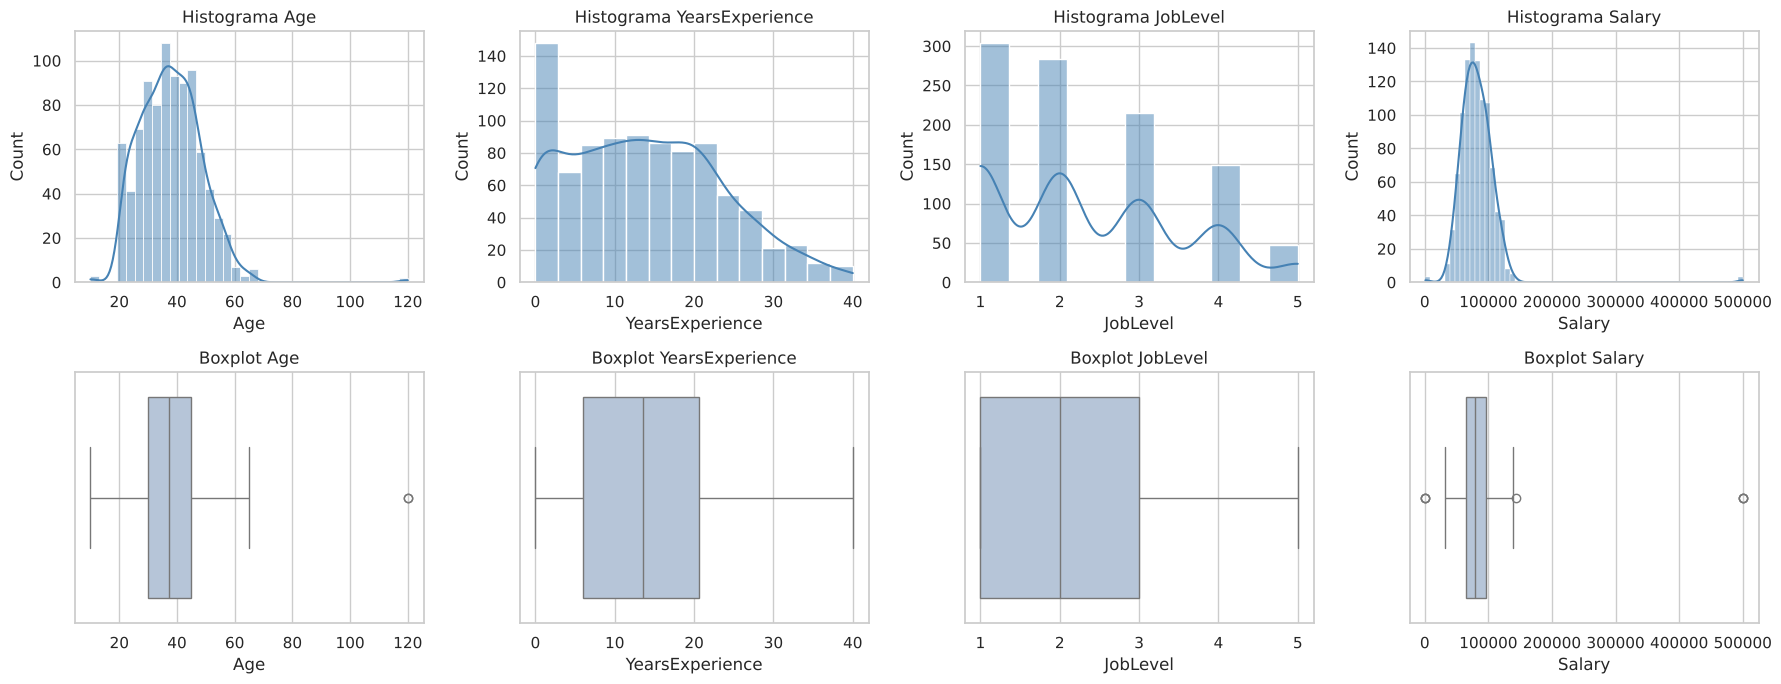

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, c in enumerate(['Age', 'YearsExperience', 'JobLevel', 'Salary']):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'Histograma {c}')
    sns.boxplot(x=df[c], ax=axes[1, i], color='lightsteelblue')
    axes[1, i].set_title(f'Boxplot {c}')
plt.tight_layout(); plt.savefig('figuras/fig1_distribuciones.png', dpi=150); plt.show()

**Hallazgos:**
- `Age` va de 10 a 120 años: hay valores imposibles para un empleado (atípicos por error).
- `Salary` tiene mínimo de USD 1.000 y máximo de USD 500.000, muy lejos del resto (USD 31.000 a 143.000): atípicos por error.
- Hay nulos en `Age` (96), `YearsExperience` (101), `Education` (105) y `Department` (109).
- `Location` tiene 40 categorías (alta cardinalidad).
- Las escalas son muy diferentes (años vs. dólares): para KNN y MLP será necesario escalar.

### 3.3 Limpieza de atípicos

**Reglas de calidad definidas desde el negocio** (no son los mínimos y máximos del dataset):

| Variable | Mínimo | Máximo | Justificación |
|---|---|---|---|
| `Age` | 18 | 70 | Edad laboral típica (mayoría de edad hasta jubilación tardía). |
| `YearsExperience` | 0 | 50 | No puede ser negativa ni superar una vida laboral. |
| `Salary` | 10.000 | 300.000 | Rango plausible para los cargos del dataset (Analyst a Director). |
| `BirthYear` | 1916 | 2008 | Coherente con la regla de edad y el año de referencia (2026). |
| `JobLevel` | 1 | 5 | Escala definida en el diccionario. |

Además, se contrasta con el criterio estadístico del rango intercuartílico (IQR).

In [10]:
reglas = {'Age': (18, 70), 'YearsExperience': (0, 50), 'Salary': (10_000, 300_000),
          'BirthYear': (1916, 2008), 'JobLevel': (1, 5)}
filas = []
for var, (lo, hi) in reglas.items():
    s = df[var].dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    filas.append({'variable': var, 'fuera_regla_negocio': int(((s < lo) | (s > hi)).sum()),
                  'fuera_IQR_1.5': int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())})
pd.DataFrame(filas)

,variable,fuera_regla_negocio,fuera_IQR_1.5
0,Age,5,2
1,YearsExperience,0,0
2,Salary,6,7
3,BirthYear,0,0
4,JobLevel,0,0


In [11]:
print('Edades fuera de regla:')
print(df[(df['Age'] < 18) | (df['Age'] > 70)][['Age', 'BirthYear', 'YearsExperience']])
print('\nSalarios fuera de regla:')
print(df_raw[(df_raw['Salary'] < 10_000) | (df_raw['Salary'] > 300_000)][['Salary', 'MonthlySalary', 'JobTitle', 'JobLevel']])

Edades fuera de regla:
       Age  BirthYear  YearsExperience
165 120.00   1,982.00            20.00
213 120.00   1,991.00            13.50
560  10.00   1,993.00             7.50
602  10.00   1,971.00            29.70
681  10.00   1,971.00            29.50

Salarios fuera de regla:
        Salary  MonthlySalary     JobTitle  JobLevel
185 500,000.00       7,644.02   Specialist         1
189 500,000.00       5,859.88  Coordinator         2
244   1,000.00       5,743.47  Coordinator         3
646 500,000.00       8,221.07     Director         2
740   1,000.00       6,355.47     Engineer         1
904   1,000.00       4,843.26     Director         1


**Decisiones:**
- **`Age` (5 registros: 10 y 120 años) → imputación.** `BirthYear` es consistente con la edad en el resto del dataset (`Age ≈ 2026 − BirthYear`), así que la edad errónea se reemplaza por `2026 − BirthYear`. No se pierde el registro.
- **`Salary` (6 registros: USD 1.000 y USD 500.000) → borrado.** Es la variable objetivo; imputarla sería inventar la respuesta que el modelo debe aprender. Su `MonthlySalary` (USD 4.800 a 8.200) confirma que son errores de captura. Se pierde el 0,6 % de los datos.
- Los atípicos que marca el IQR en `Salary` dentro del rango de negocio (salarios altos reales de cargos de nivel 4 y 5) **se conservan**: son valores válidos, no errores.

Edades corregidas: 5 | Registros eliminados por salario: 6
Nuevo tamaño: (994, 12)


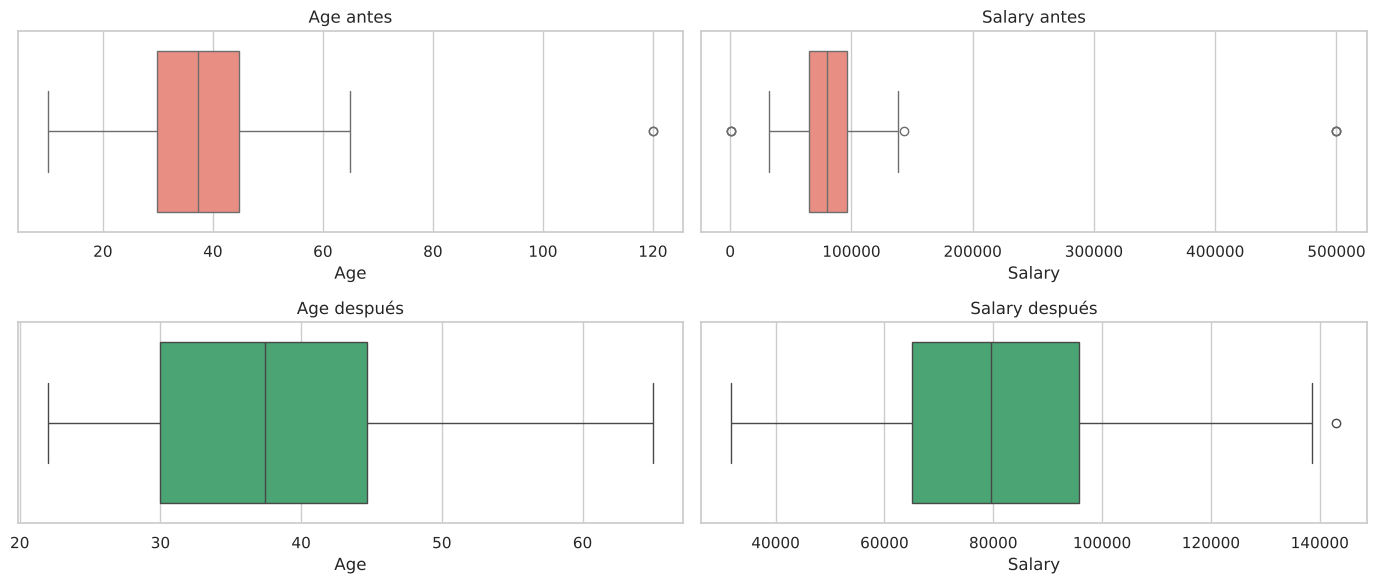

In [12]:
df_antes = df.copy()
# Age: reemplazar por la edad calculada desde BirthYear
mask_age = (df['Age'] < 18) | (df['Age'] > 70)
df.loc[mask_age, 'Age'] = 2026 - df.loc[mask_age, 'BirthYear']
# Salary: borrar registros fuera de la regla de negocio
df = df[df['Salary'].between(10_000, 300_000)].copy()
print('Edades corregidas:', mask_age.sum(), '| Registros eliminados por salario:', len(df_antes) - len(df))
print('Nuevo tamaño:', df.shape)

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for j, c in enumerate(['Age', 'Salary']):
    sns.boxplot(x=df_antes[c], ax=axes[0, j], color='salmon'); axes[0, j].set_title(f'{c} antes')
    sns.boxplot(x=df[c], ax=axes[1, j], color='mediumseagreen'); axes[1, j].set_title(f'{c} después')
plt.tight_layout(); plt.savefig('figuras/fig2_atipicos.png', dpi=150); plt.show()

### 3.4 Limpieza de nulos

In [13]:
nulos = df.isna().sum()
nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': (nulos / len(df) * 100).round(2)})
print('Registros con al menos un nulo:', round(df.isna().any(axis=1).mean() * 100, 1), '%')
nulos[nulos['nulos'] > 0]

Registros con al menos un nulo: 34.8 %


,nulos,porcentaje
Age,95,9.56
Education,105,10.56
YearsExperience,98,9.86
Department,109,10.97


Ninguna variable supera el 11 % de nulos, y los nulos están en registros distintos; borrar todas las filas con algún nulo eliminaría cerca del 35 % del dataset. Por eso se **imputa**, usando la estructura de los datos siempre que es posible:

| Variable | Método | Justificación |
|---|---|---|
| `Age` | `2026 − BirthYear` | Relación determinística verificada (coincide en el 100 % de los registros completos con diferencia máxima de ±1 año). |
| `YearsExperience` | `Age − 24`, limitado a [0, 40] | En los registros completos la brecha `Age − YearsExperience` está entre 21,5 y 26,5 años (mediana 24) y no depende de la educación. Es mejor que imputar la media global, que ignora la edad. |
| `Education` | Moda (`Bachelor`) | La educación no muestra relación con las demás variables predictoras (se verificó contra `JobLevel` y contra la brecha edad-experiencia), por lo que no hay de dónde inferirla. Se necesita un valor válido para la codificación ordinal. |
| `Department` | Nueva categoría `Unknown` | Imputar la moda inflaría artificialmente `Operations` (+109 registros). Una categoría propia conserva la información de que el dato faltaba. |

In [14]:
# Age
df['Age'] = df['Age'].fillna(2026 - df['BirthYear'])
print('Coincidencia Age vs 2026-BirthYear (±1 año):',
      round(((df['Age'].round() - (2026 - df['BirthYear'])).abs() <= 1).mean() * 100, 1), '%')

# YearsExperience
brecha = (df['Age'] - df['YearsExperience'])
print('Brecha Age - YearsExperience:'); print(brecha.describe())
print(pd.crosstab(df['Education'], pd.cut(brecha, [0, 23, 24, 25, 30]), normalize='index').round(2))
mediana_brecha = brecha.median()
df['YearsExperience'] = df['YearsExperience'].fillna((df['Age'] - mediana_brecha).clip(0, 40))

# Education y Department
print(pd.crosstab(df['JobLevel'], df['Education'].fillna('NULO'), normalize='index').round(2))
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['Department'] = df['Department'].fillna('Unknown')

# BirthYear ya cumplió su función
df = df.drop(columns='BirthYear')
print('\nNulos restantes:', df.isna().sum().sum(), '| Tamaño:', df.shape)

Coincidencia Age vs 2026-BirthYear (±1 año): 100.0 %
Brecha Age - YearsExperience:
count   896.00
mean     23.85
std       1.45
min      21.50
25%      22.20
50%      24.00
75%      25.00
max      26.50
dtype: float64
col_0        (0, 23]  (23, 24]  (24, 25]  (25, 30]
Education                                         
Bachelor        0.41      0.18      0.20      0.21
High School     0.45      0.20      0.18      0.17
Master          0.37      0.18      0.20      0.25
PhD             0.48      0.17      0.21      0.14
Education  Bachelor  High School  Master  NULO  PhD
JobLevel                                           
1              0.39         0.17    0.28  0.10 0.07
2              0.40         0.17    0.22  0.10 0.11
3              0.38         0.14    0.25  0.12 0.11
4              0.34         0.18    0.24  0.13 0.11
5              0.35         0.23    0.31  0.04 0.06

Nulos restantes: 0 | Tamaño: (994, 11)


In [15]:
df.to_csv('Employee_Salaries_limpio.csv', index=False)

### 3.5 Creación de nuevas variables (Label Encoder / One Hot Encoder)

| Variable | Tipo | Codificación |
|---|---|---|
| `Education` | Ordinal | Label (ordinal): High School=0, Bachelor=1, Master=2, PhD=3 |
| `Gender`, `Remote` | Binaria | Label: Female=0/Male=1, No=0/Yes=1 |
| `JobLevel` | Ordinal | Ya es numérica (1 a 5) |
| `CompanySize` | Ordinal en teoría | One Hot: la relación con el salario no es monotónica (Medium < Small < Large), así que un código 0-1-2 impondría un orden que los datos no respaldan |
| `JobTitle`, `Department`, `Location` | Nominal | One Hot Encoder |

Se usa One Hot sin eliminar la primera categoría porque los modelos previstos (KNN, MLP y ensambles) no sufren multicolinealidad perfecta; en un modelo lineal se usaría `drop_first=True`.

In [16]:
dfe = df.copy()
dfe['Education'] = dfe['Education'].map({'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3})
dfe['Gender'] = dfe['Gender'].map({'Female': 0, 'Male': 1})
dfe['Remote'] = dfe['Remote'].map({'No': 0, 'Yes': 1})
print(df.groupby('CompanySize')['Salary'].mean())
dfe = pd.get_dummies(dfe, columns=['CompanySize', 'JobTitle', 'Department', 'Location'], dtype=int)
print('Columnas tras codificar:', dfe.shape[1])
dfe.head()

CompanySize
Large    83,475.16
Medium   79,251.41
Small    81,223.03
Name: Salary, dtype: float64
Columnas tras codificar: 63


,Age,Gender,Education,YearsExperience,JobLevel,Remote,Salary,CompanySize_Large,CompanySize_Medium,CompanySize_Small,JobTitle_Analyst,JobTitle_Coordinator,JobTitle_Director,JobTitle_Engineer,JobTitle_Manager,JobTitle_Specialist,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Operations,Department_Sales,Department_Unknown,Location_City_001,Location_City_002,...,Location_City_016,Location_City_017,Location_City_018,Location_City_019,Location_City_020,Location_City_021,Location_City_022,Location_City_023,Location_City_024,Location_City_025,Location_City_026,Location_City_027,Location_City_028,Location_City_029,Location_City_030,Location_City_031,Location_City_032,Location_City_033,Location_City_034,Location_City_035,Location_City_036,Location_City_037,Location_City_038,Location_City_039,Location_City_040
0,22.00,0,1,0.00,5,1,"78,308.71",1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,34.40,1,1,12.40,4,1,"92,835.25",1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,30.70,1,1,6.70,2,0,"75,619.52",1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,65.00,1,0,40.00,3,0,"119,105.30",0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,24.60,0,3,0.00,4,0,"85,813.05",0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### 3.6 Análisis de relaciones

#### Análisis lineal
Correlación de Pearson entre las variables numéricas/ordinales y el salario.

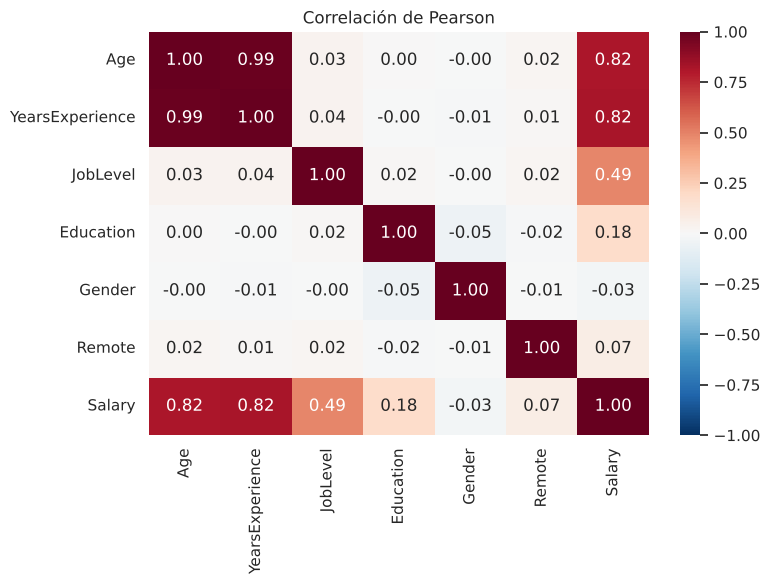

In [17]:
base = ['Age', 'YearsExperience', 'JobLevel', 'Education', 'Gender', 'Remote', 'Salary']
pearson = dfe[base].corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(pearson, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Correlación de Pearson'); plt.tight_layout()
plt.savefig('figuras/fig3_pearson.png', dpi=150); plt.show()

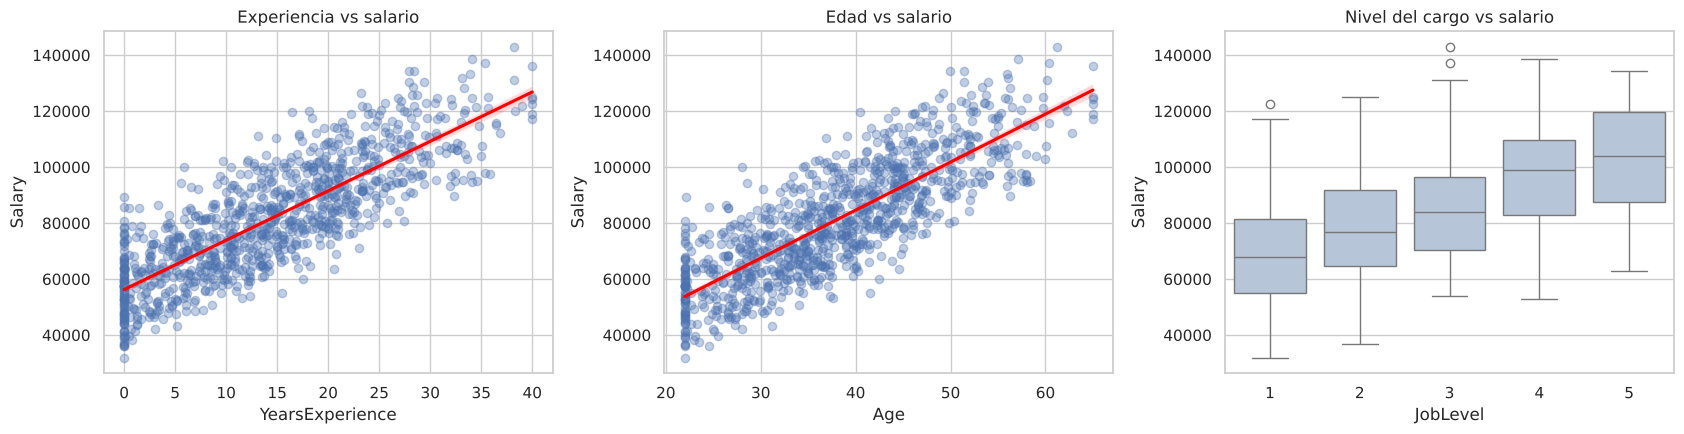

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.regplot(data=df, x='YearsExperience', y='Salary', ax=axes[0], scatter_kws={'alpha': .35}, line_kws={'color': 'red'})
sns.regplot(data=df, x='Age', y='Salary', ax=axes[1], scatter_kws={'alpha': .35}, line_kws={'color': 'red'})
sns.boxplot(data=df, x='JobLevel', y='Salary', ax=axes[2], color='lightsteelblue')
for a, t in zip(axes, ['Experiencia vs salario', 'Edad vs salario', 'Nivel del cargo vs salario']): a.set_title(t)
plt.tight_layout(); plt.savefig('figuras/fig4_dispersion.png', dpi=150); plt.show()

#### Análisis no lineal
- **Spearman:** captura relaciones monotónicas aunque no sean lineales.
- **Información mutua:** captura cualquier tipo de dependencia (no lineal, no monotónica); 0 = independencia.
- **Kruskal-Wallis + η²:** para variables categóricas nominales, prueba si la distribución del salario difiere entre categorías (no paramétrica, no asume normalidad) y mide el tamaño del efecto.

In [19]:
y = dfe['Salary']
num_pred = ['Age', 'YearsExperience', 'JobLevel', 'Education', 'Gender', 'Remote']
mi = mutual_info_regression(dfe[num_pred], y, discrete_features=[False, False, True, True, True, True], random_state=SEED)
rel_num = pd.DataFrame({
    'pearson': [stats.pearsonr(dfe[c], y)[0] for c in num_pred],
    'p_pearson': [stats.pearsonr(dfe[c], y)[1] for c in num_pred],
    'spearman': [stats.spearmanr(dfe[c], y)[0] for c in num_pred],
    'p_spearman': [stats.spearmanr(dfe[c], y)[1] for c in num_pred],
    'info_mutua': mi}, index=num_pred).sort_values('info_mutua', ascending=False)
rel_num.round(4)

,pearson,p_pearson,spearman,p_spearman,info_mutua
YearsExperience,0.82,0.00,0.82,0.00,0.58
Age,0.82,0.00,0.82,0.00,0.56
JobLevel,0.49,0.00,0.47,0.00,0.16
Education,0.18,0.00,0.18,0.00,0.02
Gender,-0.03,0.38,-0.03,0.35,0.00
Remote,0.07,0.02,0.07,0.02,0.00


In [20]:
filas = []
for c in ['JobLevel', 'Education', 'CompanySize', 'Remote', 'JobTitle', 'Location', 'Department', 'Gender']:
    grupos = [g['Salary'].values for _, g in df.groupby(c)]
    eta2 = df.groupby(c)['Salary'].transform('mean').var() / df['Salary'].var()
    filas.append({'variable': c, 'categorias': df[c].nunique(),
                  'p_kruskal': stats.kruskal(*grupos).pvalue, 'eta2': eta2})
rel_cat = pd.DataFrame(filas).set_index('variable')
rel_cat['significativa_5%'] = rel_cat['p_kruskal'] < 0.05
rel_cat.round({'p_kruskal': 6, 'eta2': 3})

,categorias,p_kruskal,eta2,significativa_5%
variable,,,,
JobLevel,5,0.00,0.24,True
Education,4,0.00,0.04,True
CompanySize,3,0.03,0.01,True
Remote,2,0.02,0.01,True
JobTitle,6,0.08,0.01,False
Location,40,0.82,0.03,False
Department,7,0.47,0.01,False
Gender,2,0.35,0.00,False


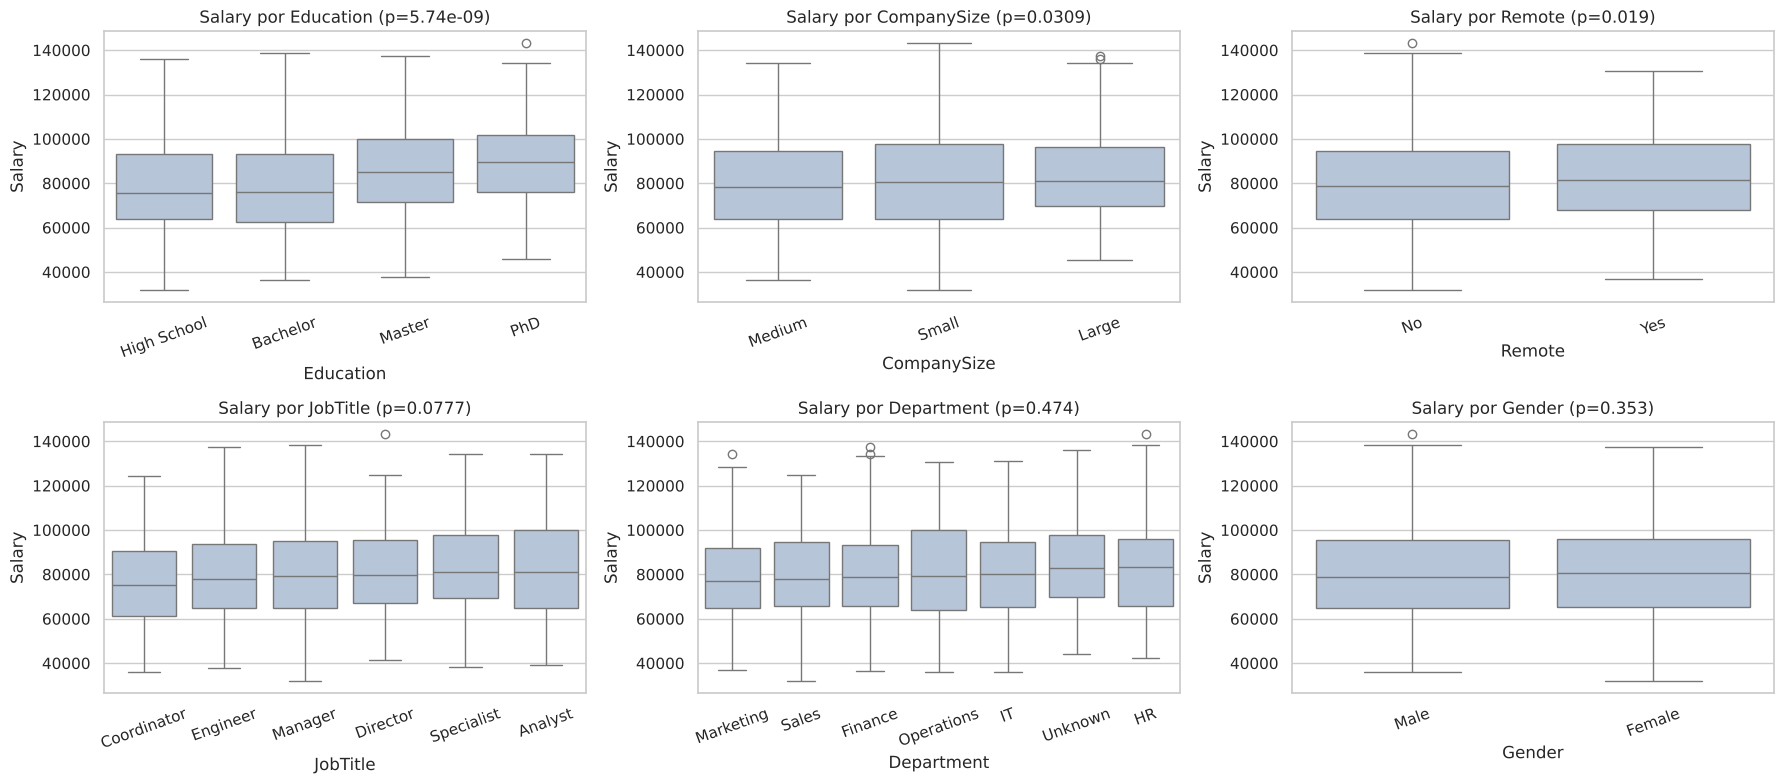

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for a, c in zip(axes.ravel(), ['Education', 'CompanySize', 'Remote', 'JobTitle', 'Department', 'Gender']):
    orden = df.groupby(c)['Salary'].median().sort_values().index
    sns.boxplot(data=df, x=c, y='Salary', order=orden, ax=a, color='lightsteelblue')
    a.set_title(f'Salary por {c} (p={rel_cat.loc[c, "p_kruskal"]:.3g})'); a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig('figuras/fig5_categoricas.png', dpi=150); plt.show()

In [22]:
print('Correlación Age vs YearsExperience:', round(df[['Age', 'YearsExperience']].corr().iloc[0, 1], 3))

Correlación Age vs YearsExperience: 0.99


**Conclusiones del análisis de relaciones:**
- `YearsExperience` (r ≈ 0,82) y `Age` (r ≈ 0,82) son las variables más relacionadas con el salario, de forma lineal (Pearson y Spearman casi iguales).
- `JobLevel` tiene relación positiva moderada (r ≈ 0,49) y es la categórica con mayor efecto (η² ≈ 0,24).
- `Education` es significativa (p < 0,001): Master y PhD ganan más que High School y Bachelor.
- `Remote` y `CompanySize` son significativas al 5 %, pero con efecto muy pequeño (η² < 0,01).
- `JobTitle`, `Department`, `Location` y `Gender` **no** son significativas (p > 0,05). El η² de `Location` (≈ 0,03) parece alto solo porque 40 grupos pequeños generan diferencias de medias por azar; la prueba de Kruskal-Wallis (p ≈ 0,82) confirma que no hay relación.
- `Age` y `YearsExperience` tienen correlación de 0,99 entre sí: son redundantes (multicolinealidad).

### 3.7 Reducción de dimensiones

#### Según el análisis anterior
| Variable | Decisión | Motivo |
|---|---|---|
| `YearsExperience` | Se conserva | Mayor relación con el salario. |
| `JobLevel` | Se conserva | Relación moderada y efecto categórico más grande. |
| `Education` | Se conserva | Significativa. |
| `Remote` | Se conserva | Significativa con efecto pequeño; solo agrega 1 columna. |
| `CompanySize` | Se conserva (3 columnas) | Significativa con efecto pequeño. |
| `Age` | Se elimina | Redundante con `YearsExperience` (r = 0,99); aporta casi la misma información y `YearsExperience` se relaciona un poco más con el salario. |
| `JobTitle` | Se elimina | No significativa (p ≈ 0,08); quitaría 6 columnas de ruido. |
| `Department` | Se elimina | No significativa; 7 columnas. |
| `Location` | Se elimina | No significativa y de alta cardinalidad (40 columnas que dispersarían las distancias en KNN). |
| `Gender` | Se elimina | No significativa y, además, usar el género para fijar salarios genera un riesgo de sesgo discriminatorio. |

Se pasa de **62 columnas codificadas a 7 predictoras.**

In [23]:
final_cols = ['YearsExperience', 'JobLevel', 'Education', 'Remote',
              'CompanySize_Small', 'CompanySize_Medium', 'CompanySize_Large']
X = dfe[final_cols]
print('Predictoras:', X.shape[1], '| Columnas antes de reducir:', dfe.shape[1] - 1)

Predictoras: 7 | Columnas antes de reducir: 62


#### Con PCA
Se aplica PCA sobre las predictoras escaladas (PCA es sensible a la escala) para ver si es posible comprimirlas más.

     varianza  acumulada
PC1      0.22       0.22
PC2      0.21       0.43
PC3      0.15       0.58
PC4      0.14       0.72
PC5      0.14       0.86
PC6      0.14       1.00
PC7      0.00       1.00


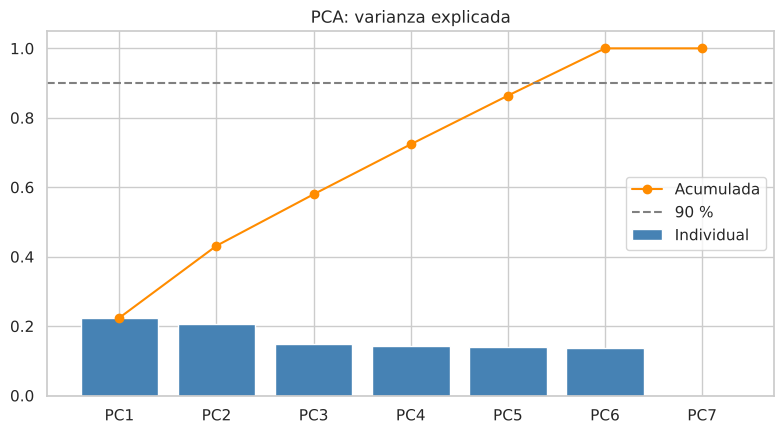

Componentes para el 90 %: 6


In [24]:
X_esc = StandardScaler().fit_transform(X)
pca = PCA(random_state=SEED).fit(X_esc)
var = pd.DataFrame({'varianza': pca.explained_variance_ratio_,
                    'acumulada': pca.explained_variance_ratio_.cumsum()},
                   index=[f'PC{i+1}' for i in range(X.shape[1])])
print(var.round(3))
plt.figure(figsize=(8, 4.5))
plt.bar(var.index, var['varianza'], color='steelblue', label='Individual')
plt.plot(var.index, var['acumulada'], 'o-', color='darkorange', label='Acumulada')
plt.axhline(0.9, ls='--', color='gray', label='90 %')
plt.title('PCA: varianza explicada'); plt.legend(); plt.tight_layout()
plt.savefig('figuras/fig6_pca.png', dpi=150); plt.show()
print('Componentes para el 90 %:', int((var['acumulada'] < 0.9).sum() + 1))

**Decisión sobre PCA: no se aplica.** La varianza está repartida entre los componentes (las predictoras restantes son casi independientes entre sí), por lo que para retener el 90 % se necesitan 6 de 7 componentes (el séptimo tiene varianza 0 porque las tres columnas de `CompanySize` siempre suman 1). PCA ahorraría muy poco y haría perder interpretabilidad (no se podría explicar el salario en términos de experiencia o nivel). La reducción por conocimiento y análisis estadístico ya fue suficiente.

### 3.8 Balanceo

**No aplica.** El balanceo (SMOTE, submuestreo, etc.) se usa en **clasificación** cuando una clase tiene muchos menos registros que otra. Este es un problema de **regresión**: la variable objetivo es continua y no tiene clases.

Lo equivalente en regresión es revisar que la distribución del objetivo no esté muy sesgada y que el conjunto de prueba la represente bien:

Asimetría de Salary: 0.242


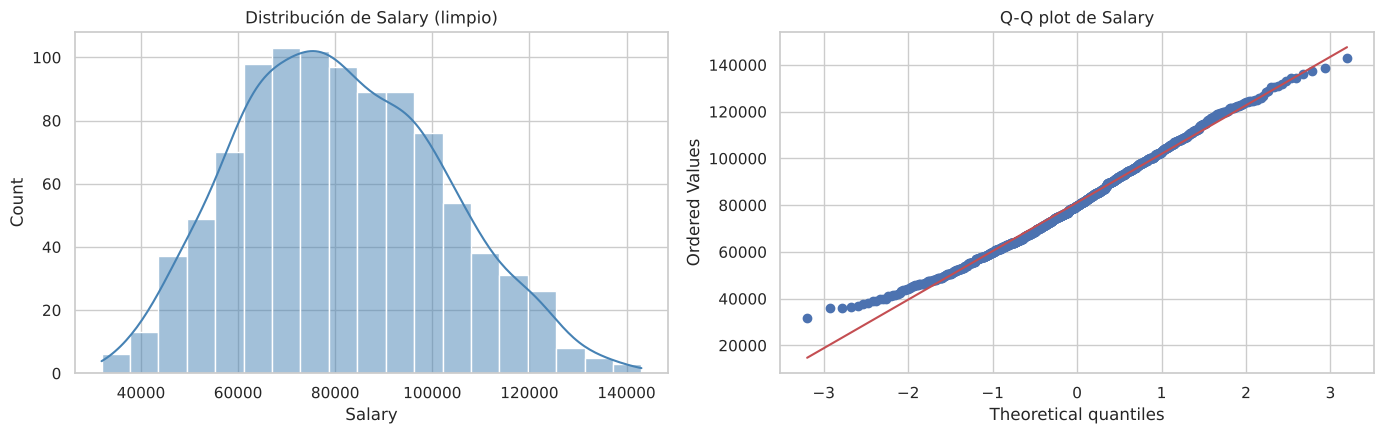

Salary_estrato
0    199
1    199
2    198
3    199
4    199
Name: count, dtype: int64


In [25]:
print('Asimetría de Salary:', round(df['Salary'].skew(), 3))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df['Salary'], kde=True, ax=ax[0], color='steelblue'); ax[0].set_title('Distribución de Salary (limpio)')
stats.probplot(df['Salary'], dist='norm', plot=ax[1]); ax[1].set_title('Q-Q plot de Salary')
plt.tight_layout(); plt.savefig('figuras/fig7_objetivo.png', dpi=150); plt.show()

# Estratos por quintil para la partición 70/30 del punto 4
dfe['Salary_estrato'] = pd.qcut(dfe['Salary'], q=5, labels=False)
print(dfe['Salary_estrato'].value_counts().sort_index())

- La asimetría de `Salary` es baja (≈ 0,24, distribución casi simétrica): no es necesario transformarla (por ejemplo, con logaritmo).
- Para el punto 4 se dejó la variable auxiliar `Salary_estrato` (quintiles) para hacer la partición 70/30 **estratificada**, de modo que entrenamiento y prueba tengan salarios bajos, medios y altos en la misma proporción. Esta columna **no** es predictora.
- El escalado (`StandardScaler`) se aplicará dentro de un `Pipeline` en el punto 4, ajustado solo con el 70 % de entrenamiento, para evitar fuga de información hacia el set de prueba.

### Exportar dataset preparado

In [26]:
preparado = dfe[final_cols + ['Salary', 'Salary_estrato']]
preparado.to_csv('Employee_Salaries_preparado.csv', index=False)
print(preparado.shape)
preparado.head()

(994, 9)


,YearsExperience,JobLevel,Education,Remote,CompanySize_Small,CompanySize_Medium,CompanySize_Large,Salary,Salary_estrato
0,0.00,5,1,1,0,0,1,"78,308.71",2
1,12.40,4,1,1,0,0,1,"92,835.25",3
2,6.70,2,1,0,0,0,1,"75,619.52",2
3,40.00,3,0,0,0,1,0,"119,105.30",4
4,0.00,4,3,0,1,0,0,"85,813.05",3


### Resumen del punto 3
| Paso | Resultado |
|---|---|
| 3.1 Selección | 19 → 12 columnas (se eliminan 6 de ruido/identificación y `MonthlySalary` por fuga). |
| 3.2 Descripción | Se detectan atípicos en `Age` y `Salary`, nulos en 4 variables y escalas muy diferentes. |
| 3.3 Atípicos | 5 edades corregidas con `BirthYear`; 6 registros con salario erróneo eliminados (1.000 → 994). |
| 3.4 Nulos | Imputación por reglas (`Age`, `YearsExperience`), moda (`Education`) y categoría `Unknown` (`Department`). 0 nulos. |
| 3.5 Codificación | Ordinal para `Education`, binaria para `Gender`/`Remote`, One Hot para las nominales (62 columnas). |
| 3.6 Relaciones | Experiencia, nivel del cargo y educación explican el salario; cargo, área, ciudad y género no. |
| 3.7 Reducción | 7 predictoras finales; PCA no se aplica. |
| 3.8 Balanceo | No aplica (regresión); partición estratificada por quintiles para el punto 4. |